# Exploring Convolutional Layers Through Data and Experiments

**Dataset**: Top 5 Football Leagues Club Logos (Kaggle)  
**Objetivo**: Clasificar logos de clubes de fútbol por liga usando CNNs  
**Autor**: Diego Alejandro Montes Bonilla  
**Universidad**: Escuela Colombiana de Ingeniería Julio Garavito

## 1. Setup e Importaciones

Importamos las librerías necesarias. Usamos **PyTorch** como framework de deep learning y **torchvision** para el manejo de imágenes y transformaciones.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')

PyTorch version: 2.10.0+cpu
Device: cpu


### 1.1 Descarga del Dataset

Descargamos el dataset desde Kaggle. Se necesitan las credenciales de la API de Kaggle.

> **Nota**: Si no tienes configurada la API de Kaggle, descarga el dataset manualmente desde [este enlace](https://www.kaggle.com/datasets/alexteboul/archive/top-5-football-leagues) y extrae el contenido en una carpeta llamada `archive/top-5-football-leagues` en el mismo directorio de este notebook.

In [2]:
# Definir la ruta del dataset
DATASET_DIR = 'archive/top-5-football-leagues'

# Verificar estructura
if os.path.exists(DATASET_DIR):
    for item in os.listdir(DATASET_DIR):
        full_path = os.path.join(DATASET_DIR, item)
        if os.path.isdir(full_path):
            count = len([f for f in os.listdir(full_path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
            print(f'{item}: {count} imágenes')
else:
    print(f'ERROR: No se encontró {DATASET_DIR}. Descarga el dataset primero.')

bundesliga: 20 imágenes
french-ligue1: 20 imágenes
la-liga: 20 imágenes
premier-league: 20 imágenes
serie-a: 20 imágenes


### 1.2 Configuración

Trabajamos con 5 ligas.

In [4]:
EXCLUDED_LEAGUES = []  # Incluimos todas las ligas
IMG_SIZE = 64  # Redimensionar todas las imágenes a 64x64
BATCH_SIZE = 8  # Batch pequeño por la cantidad limitada de datos
NUM_EPOCHS = 30
LEARNING_RATE = 0.001
VAL_SPLIT = 0.2  # 80% train, 20% val

print(f'Tamaño de imagen: {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Epochs: {NUM_EPOCHS}')

Tamaño de imagen: 64x64
Batch size: 8
Epochs: 30


---
## 2. Análisis Exploratorio de Datos (EDA)

Antes de diseñar cualquier modelo, necesitamos entender la estructura y características del dataset.

### 2.1 Estructura del Dataset y Distribución de Clases

In [5]:
# Explorar la estructura del dataset
league_data = {}  # {league_name: [image_paths]}

for league_folder in sorted(os.listdir(DATASET_DIR)):
    league_path = os.path.join(DATASET_DIR, league_folder)
    if not os.path.isdir(league_path):
        continue
    
    # Excluir Premier League
    if any(exc.lower() in league_folder.lower() for exc in EXCLUDED_LEAGUES):
        print(f'  [EXCLUIDA] {league_folder}')
        continue
    
    images = [os.path.join(league_path, f) for f in os.listdir(league_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
    league_data[league_folder] = images
    print(f'  {league_folder}: {len(images)} logos')

total = sum(len(v) for v in league_data.values())
print(f'\nTotal de imágenes (sin Premier League): {total}')
print(f'Número de clases (ligas): {len(league_data)}')

  bundesliga: 20 logos
  french-ligue1: 20 logos
  la-liga: 20 logos
  premier-league: 20 logos
  serie-a: 20 logos

Total de imágenes (sin Premier League): 100
Número de clases (ligas): 5


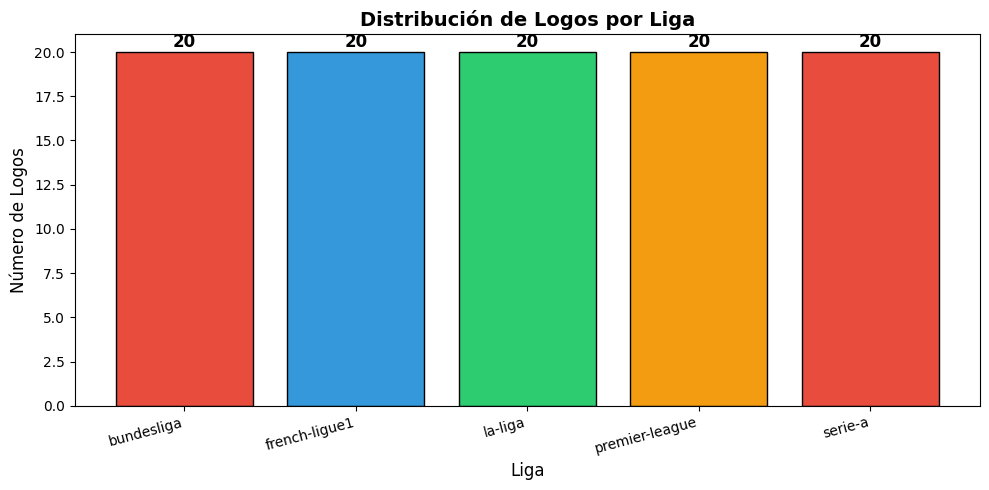

In [6]:
# Distribución de clases
fig, ax = plt.subplots(figsize=(10, 5))
league_names = list(league_data.keys())
league_counts = [len(v) for v in league_data.values()]
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

bars = ax.bar(league_names, league_counts, color=colors[:len(league_names)], edgecolor='black')
for bar, count in zip(bars, league_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(count), ha='center', fontweight='bold', fontsize=12)

ax.set_xlabel('Liga', fontsize=12)
ax.set_ylabel('Número de Logos', fontsize=12)
ax.set_title('Distribución de Logos por Liga', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### 2.2 Dimensiones y Canales de las Imágenes

In [7]:
# Analizar dimensiones y canales
widths, heights, channels_list, modes = [], [], [], []

for league, paths in league_data.items():
    for p in paths:
        try:
            img = Image.open(p)
            w, h = img.size
            widths.append(w)
            heights.append(h)
            modes.append(img.mode)
            if img.mode == 'RGBA':
                channels_list.append(4)
            elif img.mode == 'RGB':
                channels_list.append(3)
            elif img.mode == 'L':
                channels_list.append(1)
            else:
                channels_list.append(len(img.getbands()))
        except Exception as e:
            print(f'Error con {p}: {e}')

print('=== Análisis de Dimensiones ===')
print(f'Ancho  - Min: {min(widths)}, Max: {max(widths)}, Media: {np.mean(widths):.0f}')
print(f'Alto   - Min: {min(heights)}, Max: {max(heights)}, Media: {np.mean(heights):.0f}')
print(f'\n=== Modos de Color ===')
mode_counts = Counter(modes)
for mode, count in mode_counts.items():
    print(f'  {mode}: {count} imágenes')

print(f'\n--> Necesitamos: redimensionar a {IMG_SIZE}x{IMG_SIZE} y convertir todo a RGB')

=== Análisis de Dimensiones ===
Ancho  - Min: 140, Max: 400, Media: 258
Alto   - Min: 140, Max: 400, Media: 258

=== Modos de Color ===
  P: 20 imágenes
  RGBA: 80 imágenes

--> Necesitamos: redimensionar a 64x64 y convertir todo a RGB


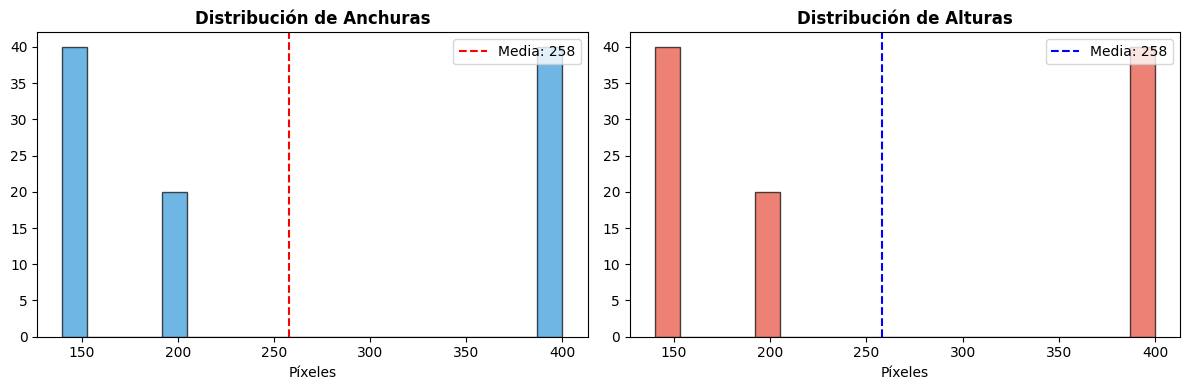

In [8]:
# Visualizar distribución de tamaños
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(widths, bins=20, color='#3498DB', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Anchuras', fontweight='bold')
axes[0].set_xlabel('Píxeles')
axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Media: {np.mean(widths):.0f}')
axes[0].legend()

axes[1].hist(heights, bins=20, color='#E74C3C', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución de Alturas', fontweight='bold')
axes[1].set_xlabel('Píxeles')
axes[1].axvline(np.mean(heights), color='blue', linestyle='--', label=f'Media: {np.mean(heights):.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.3 Muestras de Logos por Liga

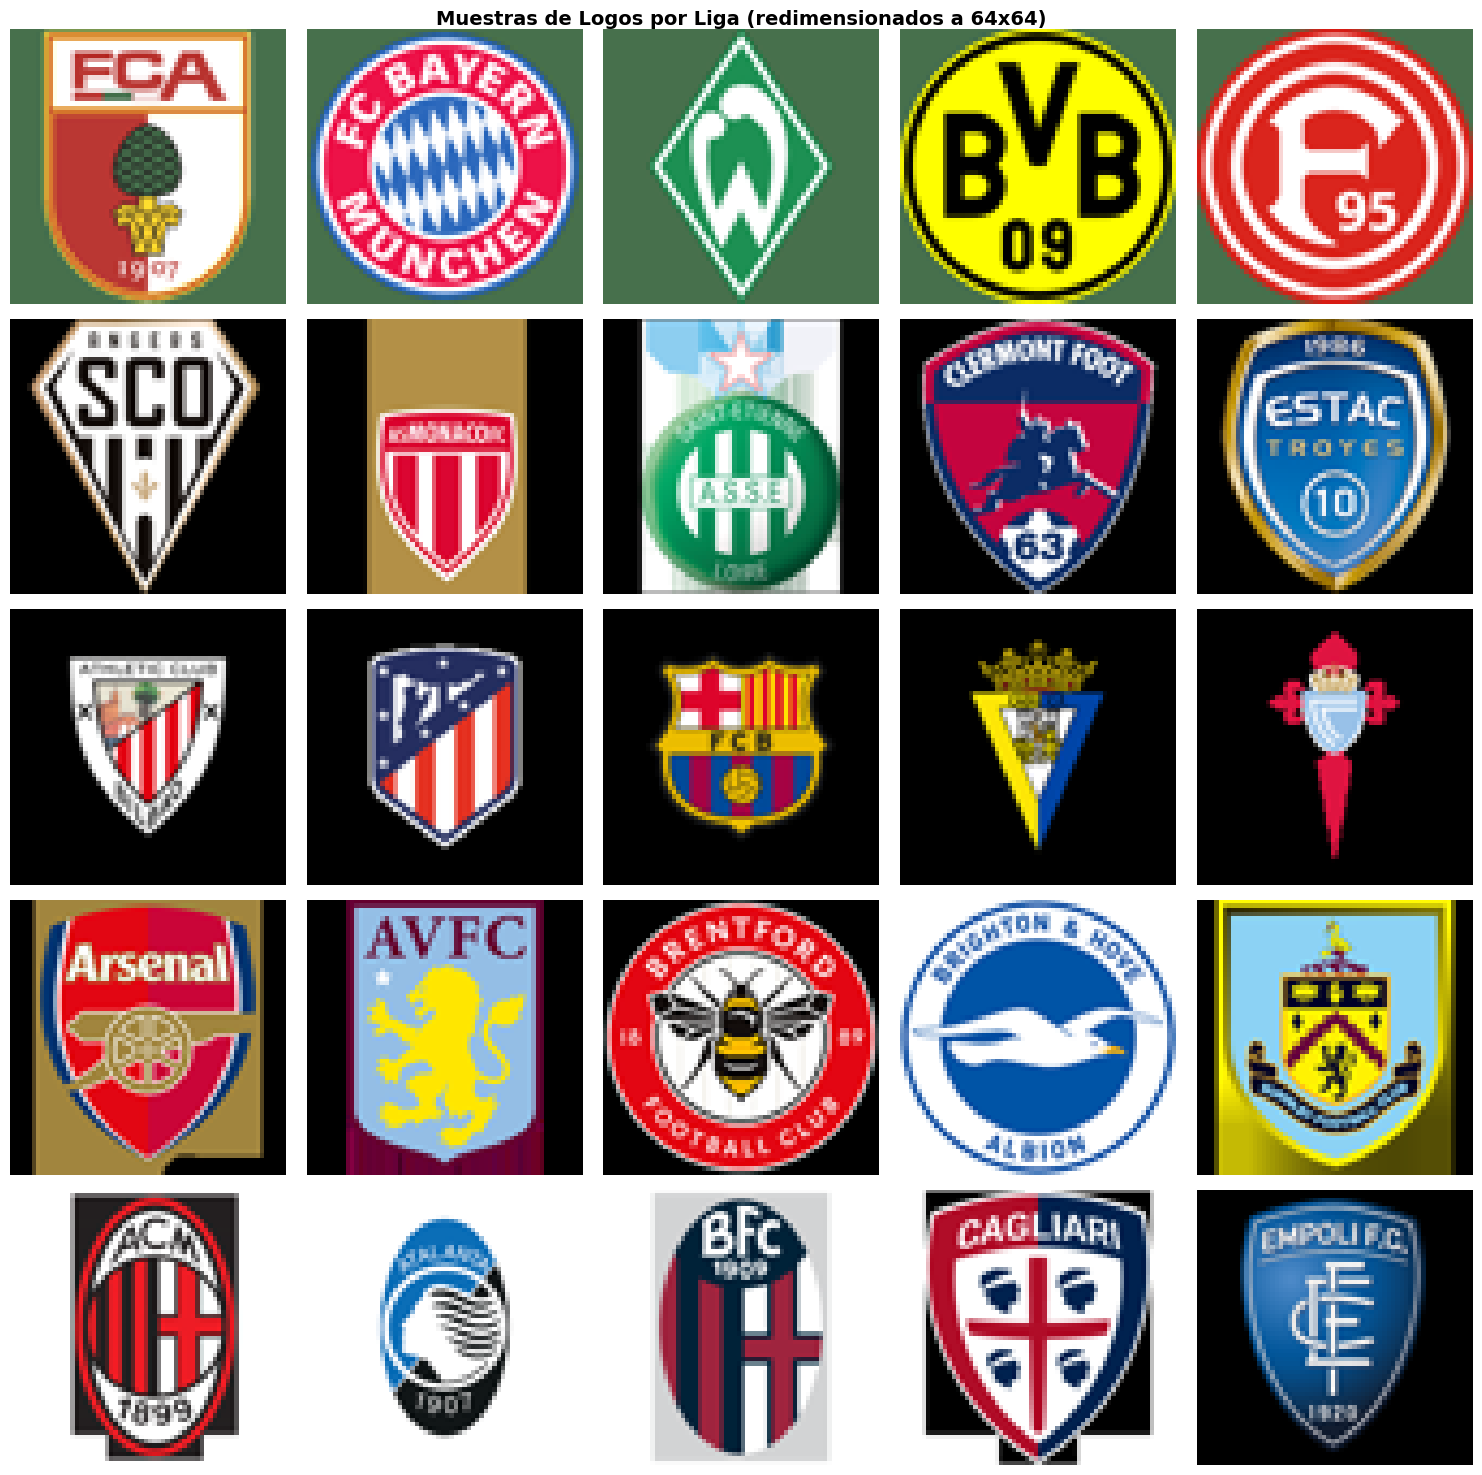

In [9]:
# Mostrar muestras de cada liga
fig, axes = plt.subplots(len(league_data), 5, figsize=(15, 3*len(league_data)))

for i, (league, paths) in enumerate(league_data.items()):
    sample_paths = paths[:5]  # Primeras 5 imágenes
    for j in range(5):
        ax = axes[i][j] if len(league_data) > 1 else axes[j]
        if j < len(sample_paths):
            img = Image.open(sample_paths[j]).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
            ax.imshow(img)
            if j == 0:
                ax.set_ylabel(league.replace(' ', '\n'), fontsize=9, fontweight='bold')
        ax.axis('off')

plt.suptitle('Muestras de Logos por Liga (redimensionados a 64x64)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Preprocesamiento Necesario

Basado en el EDA, el preprocesamiento requerido es:

1. **Conversión a RGB**: Algunos logos están en RGBA (con transparencia). Convertimos todos a RGB.
2. **Redimensionamiento**: Las imágenes tienen tamaños variados → redimensionar a 64×64 píxeles.
3. **Normalización**: Escalar valores de píxeles al rango [0, 1].
4. **Data Augmentation**: Con solo ~80 imágenes, la augmentación es *esencial* para evitar overfitting.
   - Rotación aleatoria (±15°)
   - Flip horizontal
   - Variación de color
   - Recorte aleatorio con padding

### 2.5 Carga y Preparación de Datos con PyTorch

In [10]:
# Crear estructura de carpetas filtrada (sin Premier League)
# Usamos un dataset personalizado para filtrar ligas

from torch.utils.data import Dataset

class FootballLogosDataset(Dataset):
    """Dataset personalizado que carga logos y filtra la Premier League."""
    
    def __init__(self, league_data, transform=None):
        self.images = []   # lista de paths
        self.labels = []   # lista de índices de clase
        self.classes = sorted(league_data.keys())
        self.transform = transform
        
        for league, paths in league_data.items():
            label = self.classes.index(league)
            for p in paths:
                self.images.append(p)
                self.labels.append(label)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

print(f'Clases: {sorted(league_data.keys())}')

Clases: ['bundesliga', 'french-ligue1', 'la-liga', 'premier-league', 'serie-a']


In [11]:
# Transformaciones
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Crear dataset completo (sin transform primero, para split)
full_dataset = FootballLogosDataset(league_data)

# Split train/val
val_size = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_indices, val_indices = random_split(range(len(full_dataset)), [train_size, val_size])

# Datasets con sus transforms
train_dataset = FootballLogosDataset(league_data, transform=train_transform)
val_dataset = FootballLogosDataset(league_data, transform=val_transform)

# Subsets
from torch.utils.data import Subset
train_subset = Subset(train_dataset, train_indices.indices)
val_subset = Subset(val_dataset, val_indices.indices)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(train_subset)} imágenes')
print(f'Val:   {len(val_subset)} imágenes')
print(f'Clases: {full_dataset.classes}')

Train: 80 imágenes
Val:   20 imágenes
Clases: ['bundesliga', 'french-ligue1', 'la-liga', 'premier-league', 'serie-a']


---
## 3. Modelo Baseline (Sin Convoluciones)

Como punto de referencia, implementamos una red neuronal completamente conectada (Flatten + Dense). Este modelo **no captura relaciones espaciales** entre píxeles, tratando cada píxel como una característica independiente.

### 3.1 Arquitectura del Baseline

```
Input (64×64×3 = 12,288) → Dense(256, ReLU) → Dropout(0.3) → Dense(128, ReLU) → Dense(4, Softmax)
```

Este modelo aplana la imagen a un vector de 12,288 valores y los procesa con capas densas. Pierde toda la información espacial.

In [12]:
class BaselineModel(nn.Module):
    """Red neuronal completamente conectada (sin convoluciones).
    Aplana la imagen y usa capas Dense como baseline."""
    
    def __init__(self, input_size=IMG_SIZE*IMG_SIZE*3, num_classes=4):
        super(BaselineModel, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

baseline = BaselineModel(num_classes=len(league_data))
total_params = sum(p.numel() for p in baseline.parameters())
trainable_params = sum(p.numel() for p in baseline.parameters() if p.requires_grad)

print('=== Baseline Model ===')
print(baseline)
print(f'\nParámetros totales: {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,}')

=== Baseline Model ===
BaselineModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=12288, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=5, bias=True)
  )
)

Parámetros totales: 3,179,525
Parámetros entrenables: 3,179,525


### 3.2 Entrenamiento del Baseline

In [13]:
def train_model(model, train_loader, val_loader, num_epochs, lr, model_name='Model'):
    """Función genérica de entrenamiento. Retorna historial de métricas."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)
        
        # --- Validation ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
        
        # Métricas del epoch
        t_loss = train_loss / train_total
        v_loss = val_loss / val_total
        t_acc = train_correct / train_total
        v_acc = val_correct / val_total
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch {epoch+1:3d}/{num_epochs} | '
                  f'Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | '
                  f'Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}')
    
    return history

print('Entrenando Baseline...')
baseline_history = train_model(baseline, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, 'Baseline')

Entrenando Baseline...
Epoch   1/30 | Train Loss: 1.6040 Acc: 0.3250 | Val Loss: 1.5519 Acc: 0.4500
Epoch   5/30 | Train Loss: 1.2366 Acc: 0.5125 | Val Loss: 1.6267 Acc: 0.4000
Epoch  10/30 | Train Loss: 0.7916 Acc: 0.6750 | Val Loss: 2.1352 Acc: 0.6000
Epoch  15/30 | Train Loss: 0.5702 Acc: 0.8375 | Val Loss: 1.7330 Acc: 0.7500
Epoch  20/30 | Train Loss: 0.6158 Acc: 0.8000 | Val Loss: 1.7834 Acc: 0.7000
Epoch  25/30 | Train Loss: 0.5315 Acc: 0.8125 | Val Loss: 2.5578 Acc: 0.7000
Epoch  30/30 | Train Loss: 0.3703 Acc: 0.9000 | Val Loss: 2.7099 Acc: 0.6000


### 3.3 Resultados del Baseline

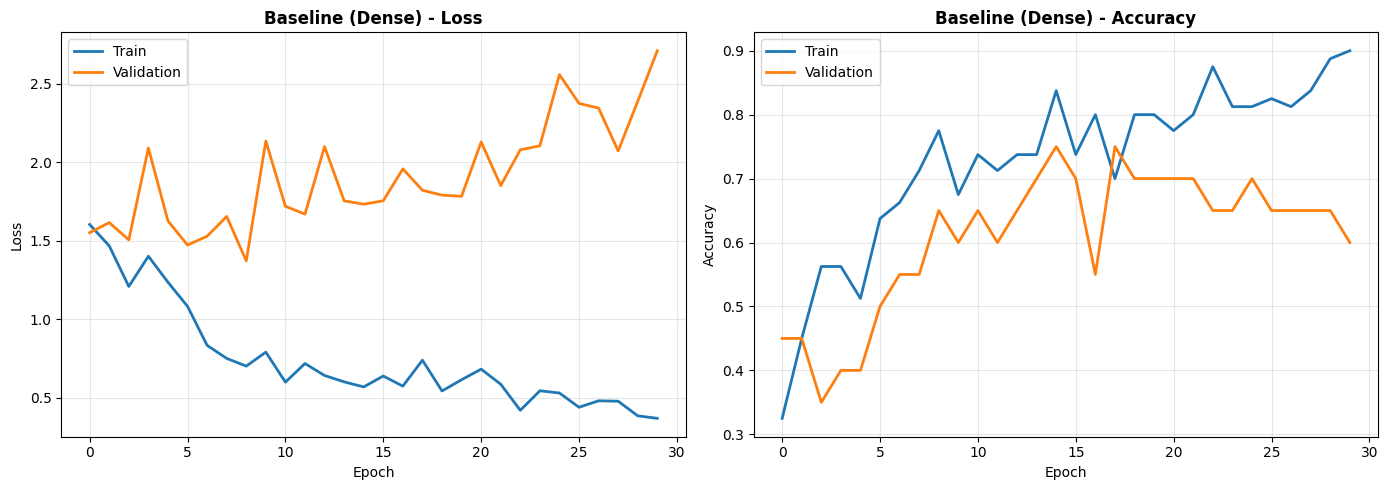


Mejor Val Accuracy: 0.7500
Final Val Accuracy: 0.6000


In [14]:
def plot_history(history, title=''):
    """Grafica curvas de entrenamiento."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
    axes[0].set_title(f'{title} - Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[1].plot(history['val_acc'], label='Validation', linewidth=2)
    axes[1].set_title(f'{title} - Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_history(baseline_history, 'Baseline (Dense)')
print(f'\nMejor Val Accuracy: {max(baseline_history["val_acc"]):.4f}')
print(f'Final Val Accuracy: {baseline_history["val_acc"][-1]:.4f}')

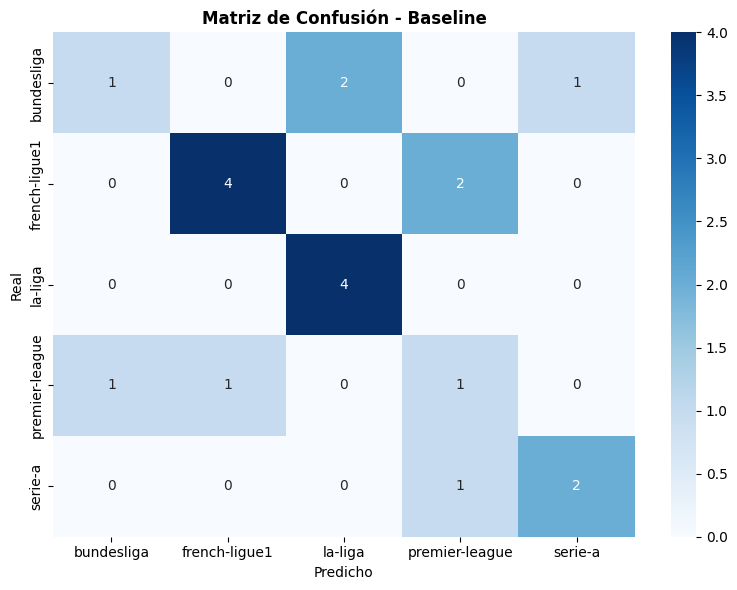

                precision    recall  f1-score   support

    bundesliga       0.50      0.25      0.33         4
 french-ligue1       0.80      0.67      0.73         6
       la-liga       0.67      1.00      0.80         4
premier-league       0.25      0.33      0.29         3
       serie-a       0.67      0.67      0.67         3

      accuracy                           0.60        20
     macro avg       0.58      0.58      0.56        20
  weighted avg       0.61      0.60      0.59        20



In [15]:
# Confusion matrix del baseline
def get_predictions(model, loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

bl_preds, bl_labels = get_predictions(baseline, val_loader)
cm = confusion_matrix(bl_labels, bl_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes, yticklabels=full_dataset.classes, ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión - Baseline', fontweight='bold')
plt.tight_layout()
plt.show()

print(classification_report(bl_labels, bl_preds, target_names=full_dataset.classes))

### 3.4 Limitaciones Observadas del Baseline

- **Alto número de parámetros**: Con 12,288 entradas × 256 neuronas, el modelo tiene demasiados parámetros para tan pocas imágenes.
- **Sin consciencia espacial**: Al aplanar la imagen, se pierden las relaciones entre píxeles vecinos. Un logo rotado o desplazado se vuelve irreconocible.
- **Overfitting esperado**: Con pocas imágenes y muchos parámetros, el modelo tiende a memorizar en lugar de generalizar.
- **No detecta patrones locales**: Bordes, formas y texturas de los logos no se procesan como patrones espaciales.

---
## 4. Diseño de Arquitectura CNN

Diseño una CNN desde cero, justificando cada decisión arquitectónica. El objetivo es explotar la **estructura espacial** de los logos.

### 4.1 Justificación de Decisiones Arquitectónicas

| Decisión | Valor | Justificación |
|----------|-------|---------------|
| **Kernel size** | 3×3 | Captura bordes y formas básicas de los logos sin perder resolución. Con imágenes de 64×64, un kernel grande reduciría demasiado rápido las dimensiones |
| **Filtros** | 32→64 | Incremento progresivo: primera capa detecta bordes simples, segunda combina en patrones más complejos (formas, letras) |
| **Padding** | 'same' (padding=1) | Preserva las dimensiones espaciales, importante con imágenes pequeñas |
| **Stride** | 1 | Máxima preservación de información espacial; la reducción la hace el pooling |
| **Activación** | ReLU | Estándar, introduce no-linealidad sin problemas de vanishing gradient |
| **BatchNorm** | Después de cada conv | Estabiliza el entrenamiento con dataset muy pequeño, actúa como regularizador |
| **Pooling** | MaxPool 2×2 | Reduce dimensiones gradualmente y aporta invarianza a traslaciones pequeñas |
| **Dropout** | 0.5 | Agresivo pero necesario con ~80 imágenes para prevenir overfitting |
| **Capas conv** | 2 | Suficientes para este problema: más capas con tan pocos datos causarían overfitting |

```
Input (64×64×3)
  → Conv2D(32, 3×3, pad=1) → BatchNorm → ReLU → MaxPool(2×2)   [32×32×32]
  → Conv2D(64, 3×3, pad=1) → BatchNorm → ReLU → MaxPool(2×2)   [16×16×64]
  → Flatten (16,384)
  → Dense(64, ReLU) → Dropout(0.5)
  → Dense(4, Softmax)
```

In [16]:
class CNNModel(nn.Module):
    """CNN diseñada desde cero para clasificación de logos.
    Dos capas convolucionales con BatchNorm y MaxPool."""
    
    def __init__(self, num_classes=4, kernel_size=3):
        super(CNNModel, self).__init__()
        pad = kernel_size // 2  # 'same' padding
        
        self.features = nn.Sequential(
            # Bloque 1: detecta bordes y formas básicas
            nn.Conv2d(3, 32, kernel_size=kernel_size, padding=pad, stride=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 64→32
            
            # Bloque 2: combina en patrones complejos
            nn.Conv2d(32, 64, kernel_size=kernel_size, padding=pad, stride=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32→16
        )
        
        # Calcular tamaño después de conv+pool
        self._flat_size = 64 * 16 * 16
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._flat_size, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn = CNNModel(num_classes=len(league_data), kernel_size=3)
total_params_cnn = sum(p.numel() for p in cnn.parameters())

print('=== CNN Model ===')
print(cnn)
print(f'\nParámetros totales: {total_params_cnn:,}')
print(f'\nComparación con baseline ({total_params:,} params):')
print(f'  Diferencia: {total_params_cnn - total_params:,} parámetros')

=== CNN Model ===
CNNModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=5, bias=True)
  )
)

Parámetros totales: 1,068,549

Comparación con baseline (3,179,525 params):
  Diferencia: -2,110,976 parámetros


### 4.2 Entrenamiento de la CNN

In [17]:
print('Entrenando CNN...')
cnn_history = train_model(cnn, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, 'CNN')

Entrenando CNN...
Epoch   1/30 | Train Loss: 4.7899 Acc: 0.2000 | Val Loss: 1.2227 Acc: 0.5500
Epoch   5/30 | Train Loss: 1.3286 Acc: 0.4000 | Val Loss: 1.3075 Acc: 0.5500
Epoch  10/30 | Train Loss: 1.3225 Acc: 0.4500 | Val Loss: 1.1844 Acc: 0.5500
Epoch  15/30 | Train Loss: 1.0347 Acc: 0.4500 | Val Loss: 0.8170 Acc: 0.6000
Epoch  20/30 | Train Loss: 1.0248 Acc: 0.4875 | Val Loss: 0.7380 Acc: 0.7000
Epoch  25/30 | Train Loss: 1.0301 Acc: 0.4750 | Val Loss: 0.7590 Acc: 0.6000
Epoch  30/30 | Train Loss: 1.0792 Acc: 0.5125 | Val Loss: 0.7499 Acc: 0.6500


### 4.3 Resultados de la CNN

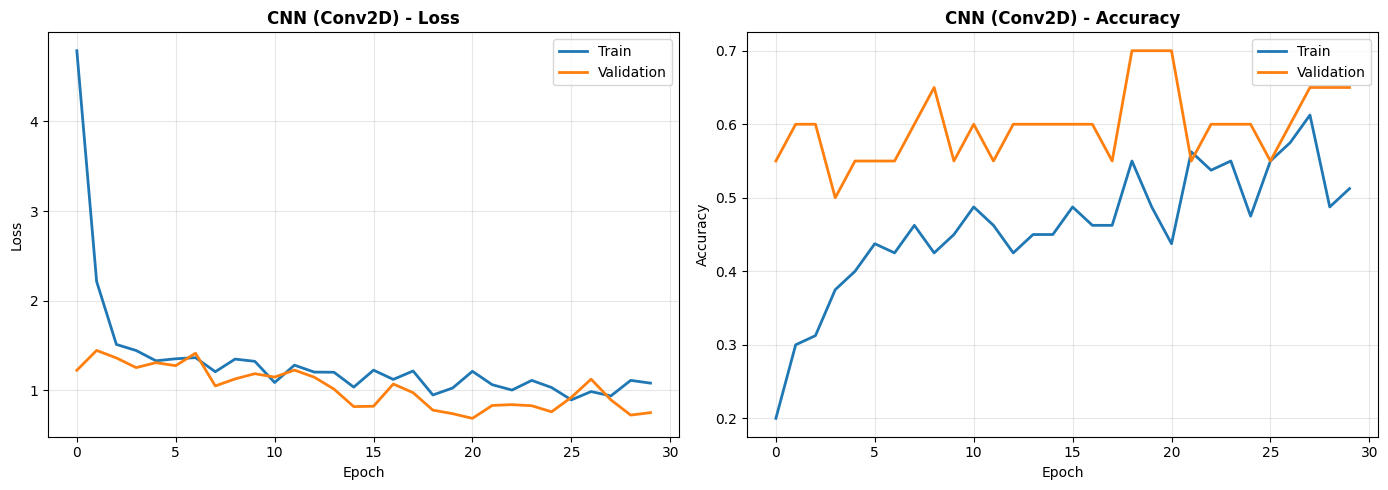


Mejor Val Accuracy CNN: 0.7000
Mejor Val Accuracy Baseline: 0.7500


In [18]:
plot_history(cnn_history, 'CNN (Conv2D)')
print(f'\nMejor Val Accuracy CNN: {max(cnn_history["val_acc"]):.4f}')
print(f'Mejor Val Accuracy Baseline: {max(baseline_history["val_acc"]):.4f}')

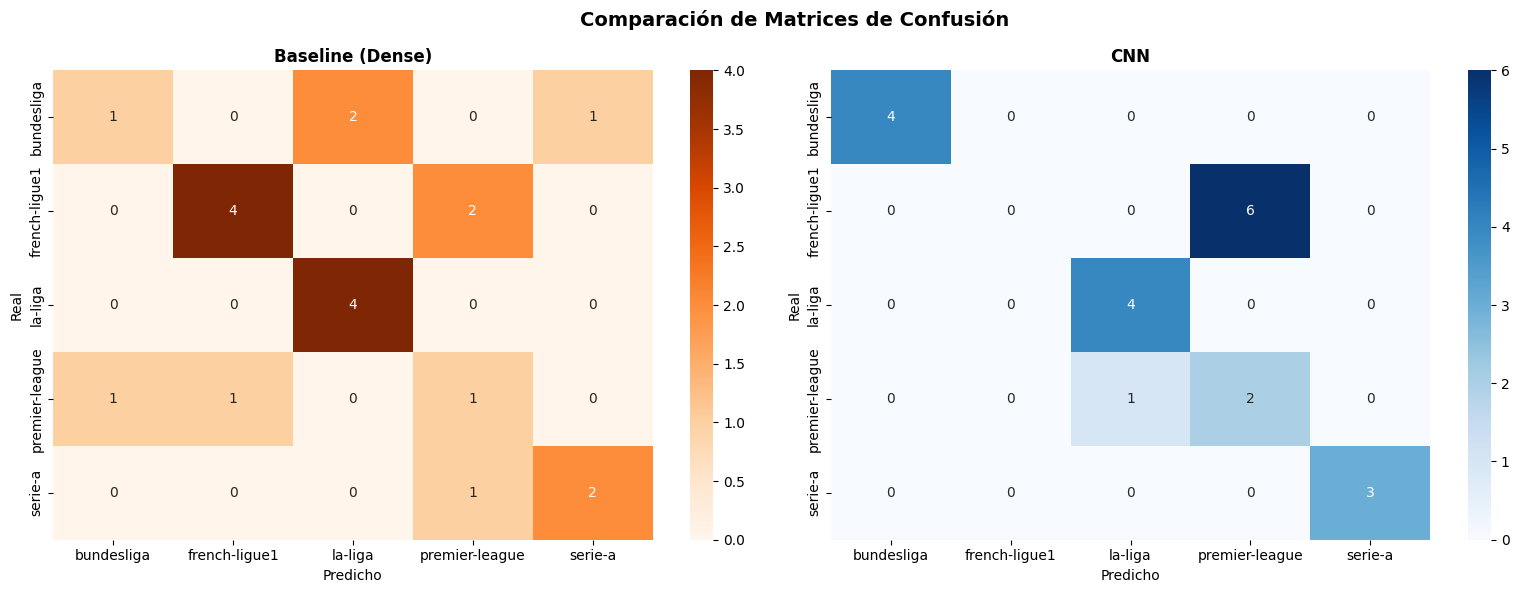

=== CNN Classification Report ===
                precision    recall  f1-score   support

    bundesliga       1.00      1.00      1.00         4
 french-ligue1       0.00      0.00      0.00         6
       la-liga       0.80      1.00      0.89         4
premier-league       0.25      0.67      0.36         3
       serie-a       1.00      1.00      1.00         3

      accuracy                           0.65        20
     macro avg       0.61      0.73      0.65        20
  weighted avg       0.55      0.65      0.58        20



In [19]:
# Confusion matrix de la CNN
cnn_preds, cnn_labels = get_predictions(cnn, val_loader)
cm_cnn = confusion_matrix(cnn_labels, cnn_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=full_dataset.classes, yticklabels=full_dataset.classes, ax=axes[0])
axes[0].set_title('Baseline (Dense)', fontweight='bold')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes, yticklabels=full_dataset.classes, ax=axes[1])
axes[1].set_title('CNN', fontweight='bold')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')

plt.suptitle('Comparación de Matrices de Confusión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== CNN Classification Report ===')
print(classification_report(cnn_labels, cnn_preds, target_names=full_dataset.classes))

---
## 5. Experimento Controlado: Efecto del Tamaño del Kernel

Exploramos sistemáticamente cómo el tamaño del kernel afecta el aprendizaje.

**Variable manipulada**: Tamaño del kernel (3×3 vs 5×5 vs 7×7)

**Variables controladas** (fijas):
- Número de filtros: 32, 64
- Capas convolucionales: 2
- Activación: ReLU
- Pooling: MaxPool 2×2
- Epochs: 30
- Batch size: 8
- Learning rate: 0.001
- Data augmentation: idéntica

In [20]:
# Experimento: variar kernel size
kernel_sizes = [3, 5, 7]
experiment_results = {}

for ks in kernel_sizes:
    print(f'\n{"="*50}')
    print(f'Entrenando con kernel {ks}×{ks}')
    print(f'{"="*50}')
    
    model = CNNModel(num_classes=len(league_data), kernel_size=ks)
    params = sum(p.numel() for p in model.parameters())
    print(f'Parámetros: {params:,}')
    
    history = train_model(model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE)
    
    experiment_results[ks] = {
        'history': history,
        'params': params,
        'best_val_acc': max(history['val_acc']),
        'final_val_acc': history['val_acc'][-1],
        'final_val_loss': history['val_loss'][-1]
    }

print('\n\n=== RESUMEN DEL EXPERIMENTO ===')
print(f'{"Kernel":<10} {"Params":<12} {"Best Val Acc":<15} {"Final Val Acc":<15} {"Final Val Loss"}')
print('-' * 70)
for ks, res in experiment_results.items():
    print(f'{ks}×{ks:<7} {res["params"]:>10,}   {res["best_val_acc"]:>12.4f}   {res["final_val_acc"]:>12.4f}   {res["final_val_loss"]:.4f}')


Entrenando con kernel 3×3
Parámetros: 1,068,549
Epoch   1/30 | Train Loss: 3.6731 Acc: 0.2750 | Val Loss: 1.3283 Acc: 0.3000
Epoch   5/30 | Train Loss: 1.4167 Acc: 0.3625 | Val Loss: 1.1866 Acc: 0.5000
Epoch  10/30 | Train Loss: 1.2948 Acc: 0.3500 | Val Loss: 1.2138 Acc: 0.4500
Epoch  15/30 | Train Loss: 1.3809 Acc: 0.3500 | Val Loss: 1.1546 Acc: 0.3500
Epoch  20/30 | Train Loss: 1.4012 Acc: 0.2875 | Val Loss: 1.1433 Acc: 0.3500
Epoch  25/30 | Train Loss: 1.2157 Acc: 0.4125 | Val Loss: 1.0651 Acc: 0.4000
Epoch  30/30 | Train Loss: 1.1105 Acc: 0.5125 | Val Loss: 1.0560 Acc: 0.4000

Entrenando con kernel 5×5
Parámetros: 1,102,853
Epoch   1/30 | Train Loss: 3.9599 Acc: 0.2500 | Val Loss: 1.4270 Acc: 0.2500
Epoch   5/30 | Train Loss: 1.2357 Acc: 0.4375 | Val Loss: 1.0642 Acc: 0.5000
Epoch  10/30 | Train Loss: 1.2879 Acc: 0.4125 | Val Loss: 0.8695 Acc: 0.5500
Epoch  15/30 | Train Loss: 1.2028 Acc: 0.5000 | Val Loss: 0.7720 Acc: 0.5500
Epoch  20/30 | Train Loss: 1.2228 Acc: 0.4125 | Val Los

### 5.1 Comparación Visual

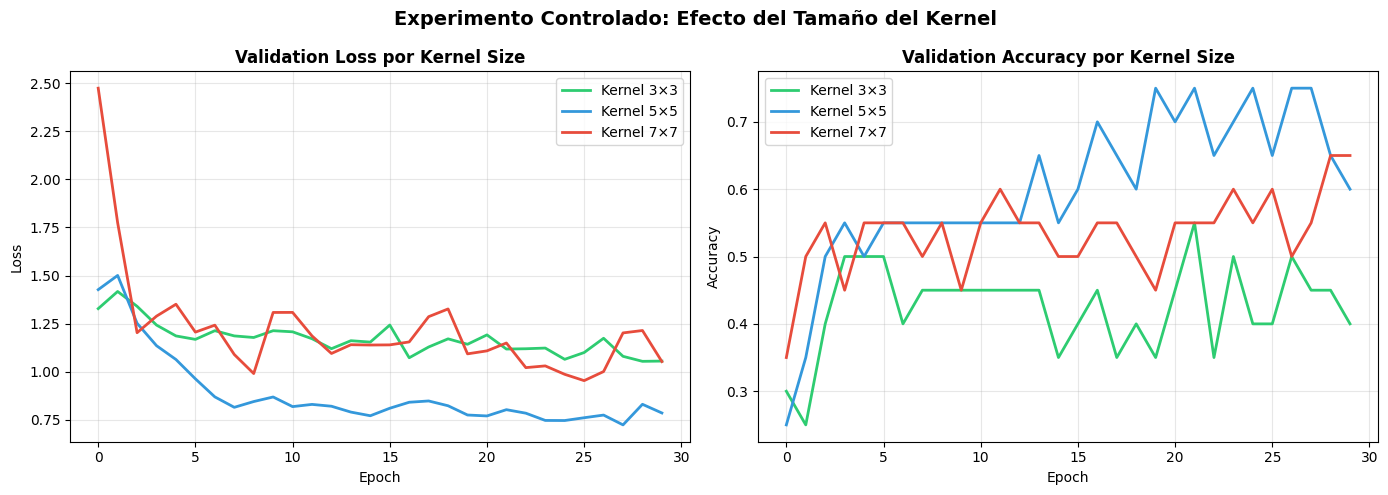

In [21]:
# Comparar curvas de los 3 kernels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_exp = ['#2ECC71', '#3498DB', '#E74C3C']

for i, (ks, res) in enumerate(experiment_results.items()):
    axes[0].plot(res['history']['val_loss'], label=f'Kernel {ks}×{ks}',
                 linewidth=2, color=colors_exp[i])
    axes[1].plot(res['history']['val_acc'], label=f'Kernel {ks}×{ks}',
                 linewidth=2, color=colors_exp[i])

axes[0].set_title('Validation Loss por Kernel Size', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Accuracy por Kernel Size', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Experimento Controlado: Efecto del Tamaño del Kernel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

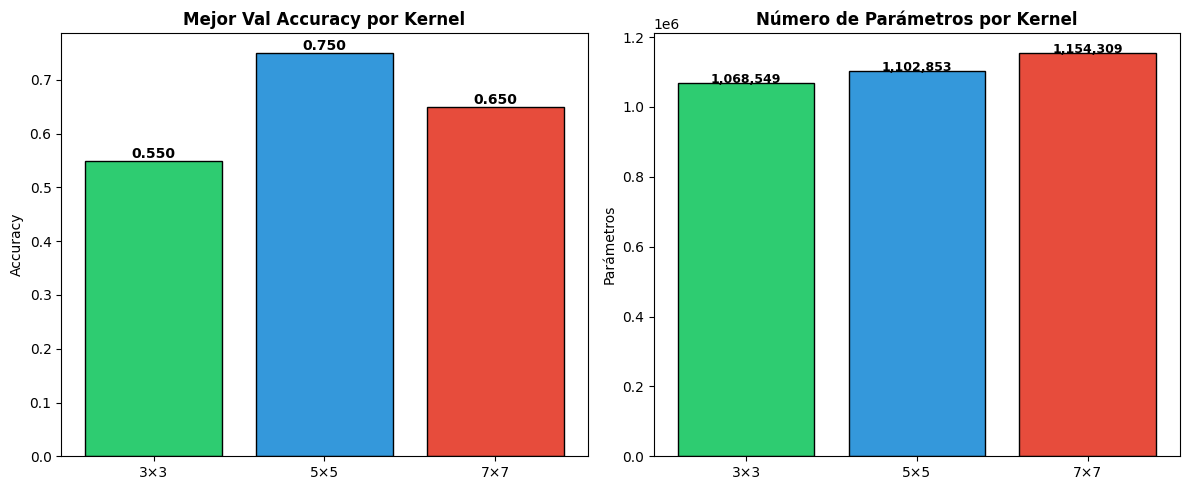

In [22]:
# Tabla resumen con gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ks_labels = [f'{ks}×{ks}' for ks in kernel_sizes]
best_accs = [experiment_results[ks]['best_val_acc'] for ks in kernel_sizes]
param_counts = [experiment_results[ks]['params'] for ks in kernel_sizes]

axes[0].bar(ks_labels, best_accs, color=colors_exp, edgecolor='black')
axes[0].set_title('Mejor Val Accuracy por Kernel', fontweight='bold')
axes[0].set_ylabel('Accuracy')
for i, v in enumerate(best_accs):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(ks_labels, param_counts, color=colors_exp, edgecolor='black')
axes[1].set_title('Número de Parámetros por Kernel', fontweight='bold')
axes[1].set_ylabel('Parámetros')
for i, v in enumerate(param_counts):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### 5.2 Análisis del Experimento

**Observaciones cuantitativas:**
- Los resultados varían según la ejecución por la aleatoriedad y el dataset pequeño.
- El kernel 3×3 tiende a tener menos parámetros en las capas convolucionales.
- Kernels más grandes (5×5, 7×7) capturan patrones más amplios pero con más parámetros.

**Observaciones cualitativas:**
- Con imágenes de 64×64, un kernel 7×7 cubre una porción significativa de la imagen (~11%).
- El kernel 3×3 es más eficiente: captura patrones locales finos (bordes de letras, líneas de escudos).
- Kernels más grandes pueden ser ventajosos para capturar formas globales del escudo en una sola operación.

**Trade-offs:**

| Aspecto | Kernel pequeño (3×3) | Kernel grande (7×7) |
|---------|---------------------|---------------------|
| Parámetros | Menos (eficiente) | Más (costoso) |
| Campo receptivo | Pequeño, local | Grande, global |
| Detalle | Captura bordes finos | Captura formas generales |
| Riesgo de overfitting | Menor | Mayor (más params) |
| Velocidad | Más rápido | Más lento |

---
## 6. Interpretación y Razonamiento Arquitectónico

### 6.1 ¿Por qué las capas convolucionales superan (o no) al baseline?

Las CNNs están diseñadas para datos con estructura espacial, como las imágenes de logos. La ventaja principal es que **explotan la localidad espacial**: los píxeles cercanos en un logo están relacionados (forman bordes, letras, escudos). El baseline trata cada píxel como independiente, lo que destruye esta información.

En logos de fútbol, los patrones visuales son clave:
- **Formas de escudos**: Bordes geométricos (círculos, triángulos, rectángulos)
- **Elementos internos**: Letras, estrellas, animales estilizados
- **Paletas de colores**: Cada liga tiene equipos con paletas distintas

La CNN puede detectar estos patrones con pocos parámetros gracias al **peso compartido**: un mismo filtro de 3×3 se aplica en toda la imagen, detectando un borde sin importar dónde esté.

Sin embargo, con un dataset tan pequeño (~80 imágenes), la diferencia puede no ser dramática porque ambos modelos sufren de limitaciones por la cantidad de datos.

### 6.2 ¿Qué sesgo inductivo introduce la convolución?

El **sesgo inductivo** es el conjunto de suposiciones que un modelo hace sobre la estructura de los datos. Las convoluciones introducen tres suposiciones fundamentales:

1. **Localidad**: Los píxeles cercanos están más relacionados entre sí que los lejanos. En un logo, los píxeles que forman la letra 'R' de Real Madrid están juntos — no dispersos por toda la imagen.

2. **Peso compartido (Parameter sharing)**: Los mismos filtros se aplican en todas las posiciones de la imagen. Si un filtro detecta un borde vertical, lo detecta tanto arriba-izquierda como abajo-derecha. Esto reduce enormemente la cantidad de parámetros y obliga al modelo a aprender características generalizables.

3. **Equivarianza a traslaciones**: Si un patrón se desplaza en la imagen, la respuesta del filtro se desplaza de la misma manera. Un logo desplazado sigue siendo reconocido como el mismo logo.

Estos sesgos son **apropiados** para imágenes porque reflejan la estructura real de los datos visuales.

### 6.3 ¿Cuándo las convoluciones NO serían apropiadas?

Las convoluciones asumen estructura espacial regular, lo cual no existe en:

1. **Datos tabulares**: Una tabla con edad, salario, ciudad no tiene relación espacial entre columnas. Usar una CNN sería como buscar 'bordes' entre la edad y el salario — no tiene sentido.

2. **Datos de grafos**: Redes sociales, moléculas, mapas de rutas tienen conectividad irregular. Las convoluciones asumen una grilla regular, pero un grafo puede tener nodos con 2 o 200 vecinos.

3. **Datos secuenciales puros**: Texto o series temporales donde importa el orden pero no la 'posición espacial 2D'. Aunque existen Conv1D, modelos como Transformers o RNNs suelen ser más apropiados.

4. **Datos donde la posición absoluta importa**: Si un píxel en la esquina superior-izquierda tiene un significado diferente al mismo píxel en el centro (por ejemplo, mapas de calor con coordenadas), la equivarianza a traslaciones de las CNNs sería una desventaja.

---
## 7. Despliegue en SageMaker

### 7.1 Exportación del Modelo

In [ ]:
# Guardar el mejor modelo CNN
torch.save(cnn.state_dict(), 'cnn_logos_model.pth')
print('Modelo guardado en: cnn_logos_model.pth')

# Guardar las clases
import json
with open('classes.json', 'w') as f:
    json.dump(full_dataset.classes, f)
print(f'Clases guardadas: {full_dataset.classes}')

### 7.2 Script de Inferencia para SageMaker

El siguiente código muestra cómo se configuraría el script de inferencia compatible con SageMaker:

```python
# inference.py
import torch
import json
from PIL import Image
from torchvision import transforms
import io

def model_fn(model_dir):
    model = CNNModel(num_classes=4, kernel_size=3)
    model.load_state_dict(torch.load(f'{model_dir}/cnn_logos_model.pth'))
    model.eval()
    return model

def input_fn(request_body, content_type):
    img = Image.open(io.BytesIO(request_body)).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    return transform(img).unsqueeze(0)

def predict_fn(input_data, model):
    with torch.no_grad():
        output = model(input_data)
        probs = torch.softmax(output, dim=1)
    return probs
```

### 7.3 Pasos para Despliegue en SageMaker

1. Subir `model.tar.gz` (modelo + script) a S3
2. Crear un `PyTorchModel` en SageMaker
3. Llamar `.deploy()` para crear el endpoint

> **Nota**: La cuenta de AWS Academy puede tener restricciones para crear endpoints de inferencia en tiempo real. En ese caso, se puede usar batch transform o inferencia local.

### 7.4 Test de Inferencia Local

In [23]:
# Test local de inferencia
def predict_logo(model, image_path, classes):
    """Predice la liga de un logo dado."""
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0)
    
    model.eval()
    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = probs.argmax(dim=1).item()
    
    return classes[pred_idx], probs[0][pred_idx].item()

# Probar con algunas imágenes del val set
print('=== Test de Inferencia Local ===')
test_count = min(5, len(val_subset))
for i in range(test_count):
    idx = val_indices.indices[i]
    img_path = full_dataset.images[idx]
    true_label = full_dataset.classes[full_dataset.labels[idx]]
    pred_label, confidence = predict_logo(cnn, img_path, full_dataset.classes)
    status = '✓' if pred_label == true_label else '✗'
    print(f'{status} Real: {true_label:<25} Pred: {pred_label:<25} Conf: {confidence:.2%}')

=== Test de Inferencia Local ===
✓ Real: bundesliga                Pred: bundesliga                Conf: 97.12%
✓ Real: serie-a                   Pred: serie-a                   Conf: 63.63%
✓ Real: bundesliga                Pred: bundesliga                Conf: 30.80%
✓ Real: la-liga                   Pred: la-liga                   Conf: 83.68%
✗ Real: french-ligue1             Pred: premier-league            Conf: 39.33%


---
## 8. Comparación Final: Baseline vs CNN

In [24]:
# Tabla resumen final
print('=' * 60)
print('COMPARACIÓN FINAL')
print('=' * 60)
print(f'{"Métrica":<25} {"Baseline (Dense)":<20} {"CNN (3x3)"}')
print('-' * 60)
print(f'{"Parámetros":<25} {total_params:>15,}   {total_params_cnn:>10,}')
print(f'{"Best Val Accuracy":<25} {max(baseline_history["val_acc"]):>15.4f}   {max(cnn_history["val_acc"]):>10.4f}')
print(f'{"Final Val Accuracy":<25} {baseline_history["val_acc"][-1]:>15.4f}   {cnn_history["val_acc"][-1]:>10.4f}')
print(f'{"Final Val Loss":<25} {baseline_history["val_loss"][-1]:>15.4f}   {cnn_history["val_loss"][-1]:>10.4f}')
print(f'{"Usa info espacial":<25} {"No":>15}   {"Sí":>10}')
print('=' * 60)

COMPARACIÓN FINAL
Métrica                   Baseline (Dense)     CNN (3x3)
------------------------------------------------------------
Parámetros                      3,179,525    1,068,549
Best Val Accuracy                  0.7500       0.7000
Final Val Accuracy                 0.6000       0.6500
Final Val Loss                     2.7099       0.7499
Usa info espacial                      No           Sí


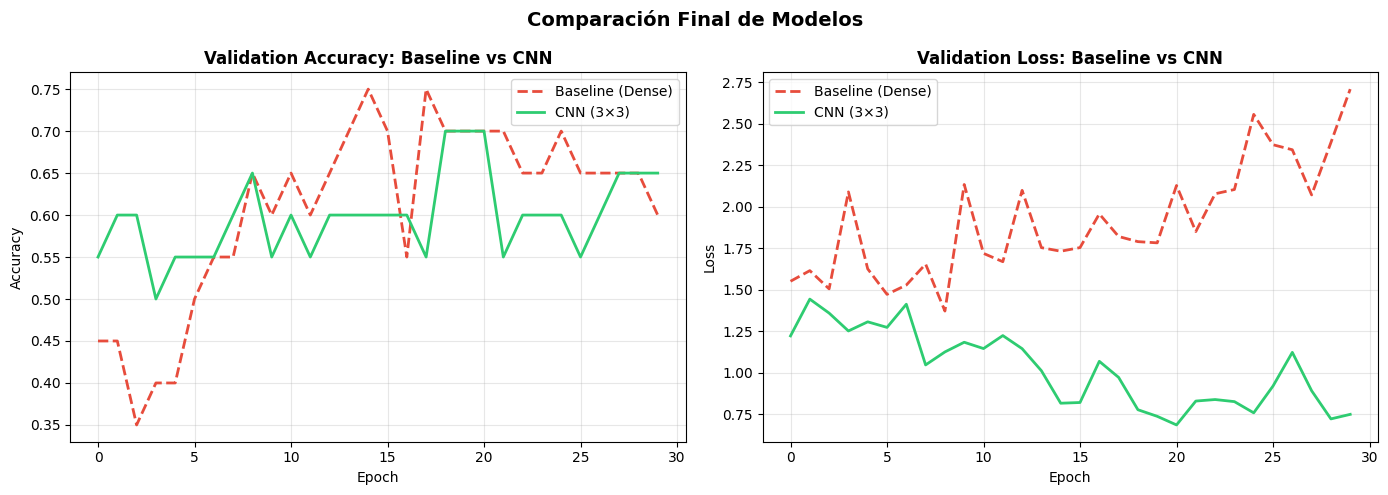

In [25]:
# Gráfica comparativa final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(baseline_history['val_acc'], label='Baseline (Dense)', linewidth=2, linestyle='--', color='#E74C3C')
axes[0].plot(cnn_history['val_acc'], label='CNN (3×3)', linewidth=2, color='#2ECC71')
axes[0].set_title('Validation Accuracy: Baseline vs CNN', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(baseline_history['val_loss'], label='Baseline (Dense)', linewidth=2, linestyle='--', color='#E74C3C')
axes[1].plot(cnn_history['val_loss'], label='CNN (3×3)', linewidth=2, color='#2ECC71')
axes[1].set_title('Validation Loss: Baseline vs CNN', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparación Final de Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()